# Write a program in python to demonstrate Handwritten Digit Recognition on MNIST dataset

In [20]:
from tensorflow import argmax
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [3]:
train_images, test_images = (train_images / 255.0).reshape(-1, 28, 28, 1), (test_images / 255.0).reshape(-1, 28, 28, 1)
train_labels, test_labels = to_categorical(train_labels), to_categorical(test_labels)

In [9]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax'),
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.fit(train_images, train_labels, epochs=5, verbose=0);

In [12]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0731


In [14]:
print(f"Test accuracy:{test_acc}\nTest loss: {test_loss}")

Test accuracy:0.9775999784469604
Test loss: 0.07308879494667053


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


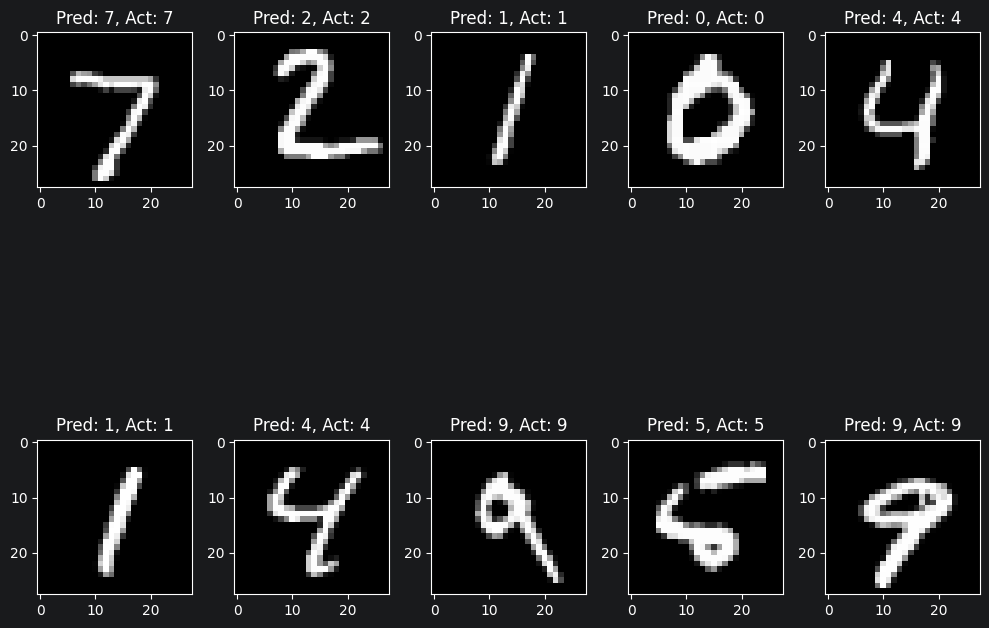

In [25]:
predictions = model.predict(test_images)
predicted_labels, true_labels = argmax(predictions, axis=1), argmax(test_labels, axis=1)

plt.figure(figsize=(10, 10))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i], cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}, Act: {true_labels[i]}")

plt.tight_layout()
plt.show()